# Safwan's MovieLens Dashboard  
**Week 3 Dashboard Exercise**  

This notebook explores the MovieLens dataset to analyze movie ratings by genre, release year, and viewer demographics.  


## Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Configure Seaborn
sns.set(style="whitegrid", palette="muted", font_scale=1.1)


## Load Data

In [4]:
# Load dataset
df = pd.read_csv("/workspaces/ds-dev-fall-2025/Week-03-EDA-and-Dashboards/exercise/safwan_dashboard/movie_ratings.csv")

# Quick check
print(df.info())
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212595 entries, 0 to 212594
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   user_id      212595 non-null  int64  
 1   movie_id     212595 non-null  int64  
 2   rating       212595 non-null  int64  
 3   timestamp    212595 non-null  object 
 4   age          212595 non-null  int64  
 5   gender       212595 non-null  object 
 6   occupation   212595 non-null  object 
 7   zip_code     212595 non-null  object 
 8   title        212595 non-null  object 
 9   year         212559 non-null  float64
 10  decade       212559 non-null  float64
 11  genres       212595 non-null  object 
 12  rating_year  212595 non-null  int64  
dtypes: float64(2), int64(5), object(6)
memory usage: 21.1+ MB
None


,user_id,movie_id,rating,timestamp,age,gender,occupation,zip_code,title,year,decade,genres,rating_year
0,196,242,3,1997-12-04 15:55:49,49,M,writer,55105,Kolya (1996),1996.0,1990.0,Comedy,1997
1,186,302,3,1998-04-04 19:22:22,39,F,executive,00000,L.A. Confidential (1997),1997.0,1990.0,Crime,1998
2,186,302,3,1998-04-04 19:22:22,39,F,executive,00000,L.A. Confidential (1997),1997.0,1990.0,Film-Noir,1998
3,186,302,3,1998-04-04 19:22:22,39,F,executive,00000,L.A. Confidential (1997),1997.0,1990.0,Mystery,1998
4,186,302,3,1998-04-04 19:22:22,39,F,executive,00000,L.A. Confidential (1997),1997.0,1990.0,Thriller,1998


## 1. Breakdown of genres for rated movies
We need to count how many ratings each genre received.  


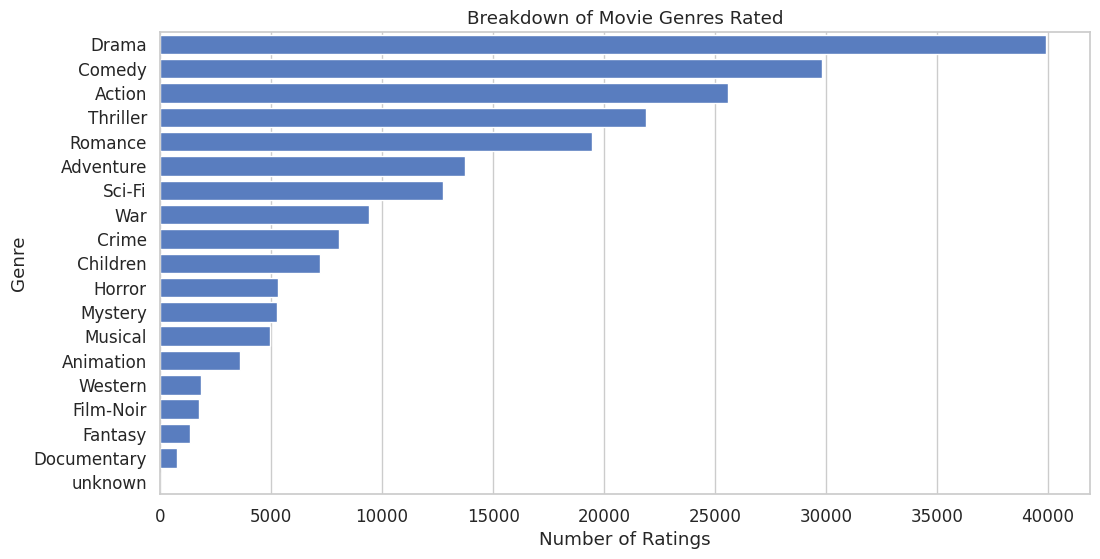

In [5]:
# Explode genres (split pipe-separated values into rows)
df_exploded = df.assign(genres=df["genres"].str.split("|")).explode("genres")

# Count plot
plt.figure(figsize=(12,6))
sns.countplot(data=df_exploded, y="genres", order=df_exploded["genres"].value_counts().index)
plt.title("Breakdown of Movie Genres Rated")
plt.xlabel("Number of Ratings")
plt.ylabel("Genre")
plt.show()


## 2. Which genres have the highest viewer satisfaction?  
We calculate the **mean rating per genre** to find which genres viewers rated highest.  


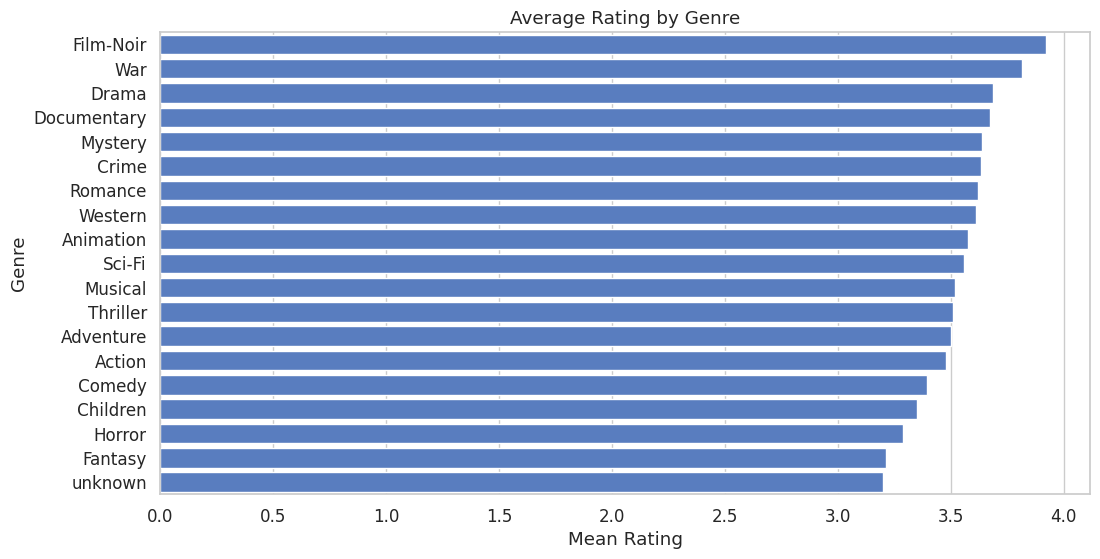

In [6]:

genre_ratings = df_exploded.groupby("genres")["rating"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=genre_ratings.values, y=genre_ratings.index)
plt.title("Average Rating by Genre")
plt.xlabel("Mean Rating")
plt.ylabel("Genre")
plt.show()


## 3. Mean rating across movie release years  
We examine how ratings change over the years movies were released.  


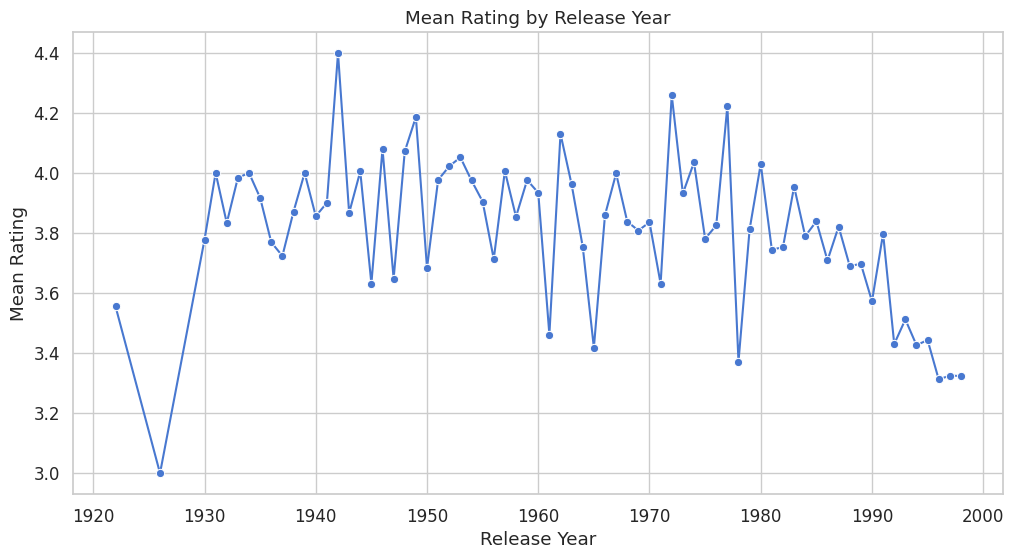

In [7]:
ratings_by_year = df.groupby("year")["rating"].mean()

plt.figure(figsize=(12,6))
sns.lineplot(x=ratings_by_year.index, y=ratings_by_year.values, marker="o")
plt.title("Mean Rating by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Mean Rating")
plt.show()


## 4. Best-rated movies with thresholds  
We find the **top 5 best-rated movies** with at least 50 ratings, and then with at least 150 ratings.  


In [8]:
movie_stats = df.groupby("title").agg(
    mean_rating=("rating", "mean"),
    num_ratings=("rating", "count")
)

best_50 = movie_stats[movie_stats["num_ratings"] >= 50].sort_values("mean_rating", ascending=False).head(5)
print("Top 5 movies with at least 50 ratings:\n", best_50)

best_150 = movie_stats[movie_stats["num_ratings"] >= 150].sort_values("mean_rating", ascending=False).head(5)
print("\nTop 5 movies with at least 150 ratings:\n", best_150)


Top 5 movies with at least 50 ratings:
                                                     mean_rating  num_ratings
title                                                                       
Close Shave, A (1995)                                  4.491071          336
Schindler's List (1993)                                4.466443          596
Wrong Trousers, The (1993)                             4.466102          236
Casablanca (1942)                                      4.456790          729
Wallace & Gromit: The Best of Aardman Animation...     4.447761           67

Top 5 movies with at least 150 ratings:
                                   mean_rating  num_ratings
title                                                     
Close Shave, A (1995)                4.491071          336
Schindler's List (1993)              4.466443          596
Wrong Trousers, The (1993)           4.466102          236
Casablanca (1942)                    4.456790          729
Shawshank Redemption, The

## Extra Credit 1: Ratings vs Age by Genre  
We plot how ratings vary across **age groups** for selected genres.  


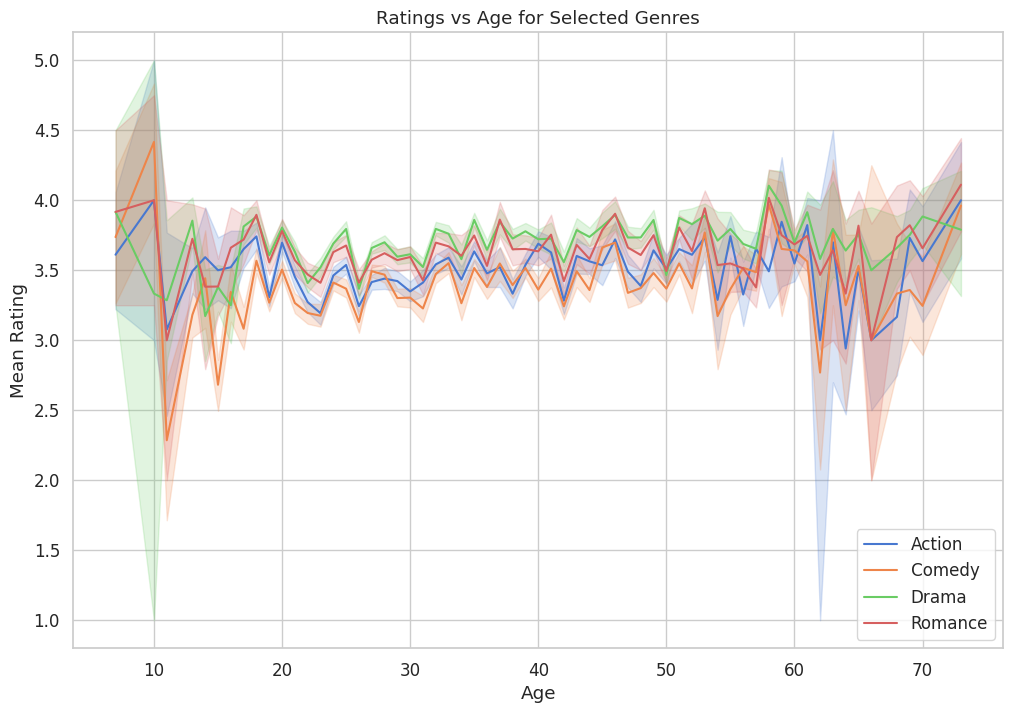

In [9]:
selected_genres = ["Action", "Comedy", "Drama", "Romance"]

plt.figure(figsize=(12,8))
for genre in selected_genres:
    temp = df_exploded[df_exploded["genres"] == genre]
    sns.lineplot(x=temp["age"], y=temp["rating"], label=genre)

plt.title("Ratings vs Age for Selected Genres")
plt.xlabel("Age")
plt.ylabel("Mean Rating")
plt.legend()
plt.show()


## Extra Credit 2: Number of Ratings vs Mean Rating per Genre  
We check if there’s a correlation between how many ratings a genre has and its average rating.  


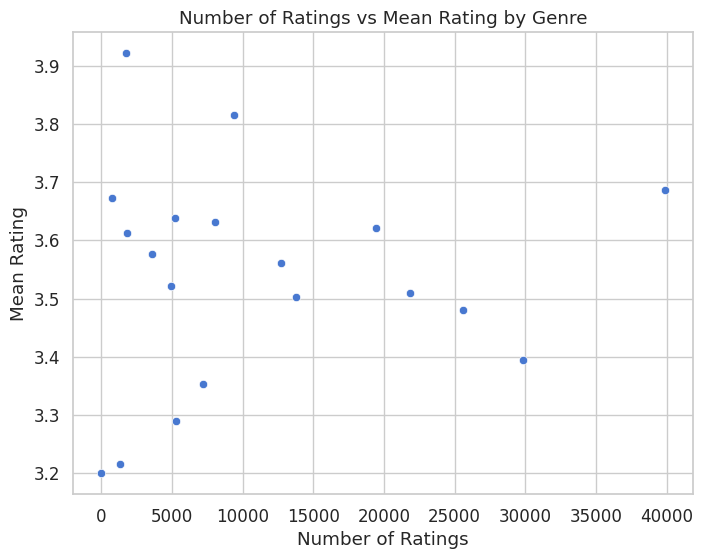

In [10]:
genre_stats = df_exploded.groupby("genres").agg(
    mean_rating=("rating", "mean"),
    num_ratings=("rating", "count")
)

plt.figure(figsize=(8,6))
sns.scatterplot(data=genre_stats, x="num_ratings", y="mean_rating")
plt.title("Number of Ratings vs Mean Rating by Genre")
plt.xlabel("Number of Ratings")
plt.ylabel("Mean Rating")
plt.show()
